# LC Index E2E Test - Basic Functionality on Notebook 7

- Test that LC Index extension works properly on Notebook 7
- Verify that Index tab appears in left sidebar
- Verify that README.svg and README.md are displayed
- Test link functionality from Index to notebooks

In [6]:
notebook7_url = "http://localhost:8888/tree?token=test-token"
default_result_path = None
close_on_fail = False
transition_timeout = 10000
default_delay = 200
browser_type = "chromium"
jupyter_work_dir = '../artifacts/jupyter-work'

In [7]:
import tempfile

work_dir = tempfile.mkdtemp()
if default_result_path is None:
    default_result_path = work_dir
work_dir

'/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmptv19esji'

In [8]:
import re
import asyncio
import importlib

import scripts.playwright
importlib.reload(scripts.playwright)

from scripts.playwright import *

import scripts.jupyterlab as jupyterlab
importlib.reload(jupyterlab)

await init_pw_context(close_on_fail=close_on_fail, last_path=default_result_path, delay=default_delay, browser_type=browser_type)

('20251114-090739',
 '/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpn8gj44f6')

## Open Notebook 7 and wait for it to load

Start epoch: 1763078859.924371 seconds


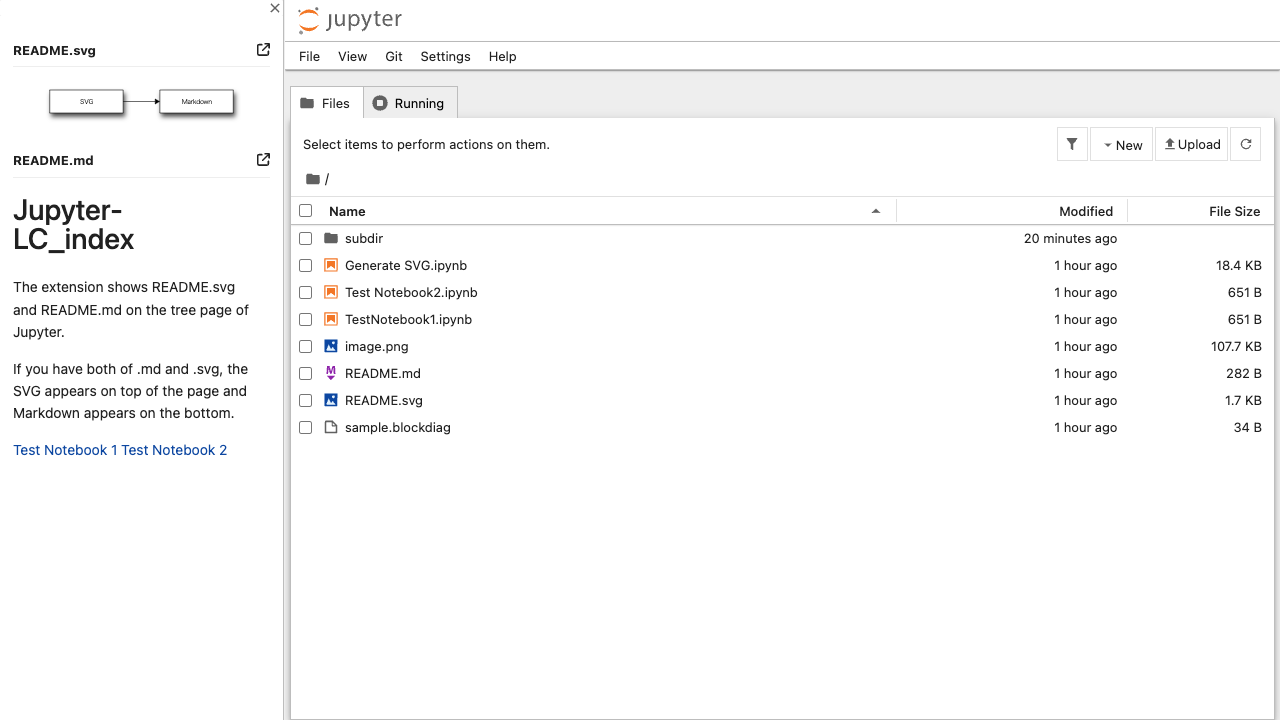

In [9]:
tree_page = None

async def _step(page):
    await page.goto(notebook7_url)

    # Wait for Notebook 7 file browser to load
    await expect(page.locator('.jp-DirListing')).to_be_visible(timeout=transition_timeout)

    global tree_page
    tree_page = page

await run_pw(_step)

## Verify that Index tab appears in left sidebar

Start epoch: 1763078861.003221 seconds
Index widget is automatically visible in left sidebar


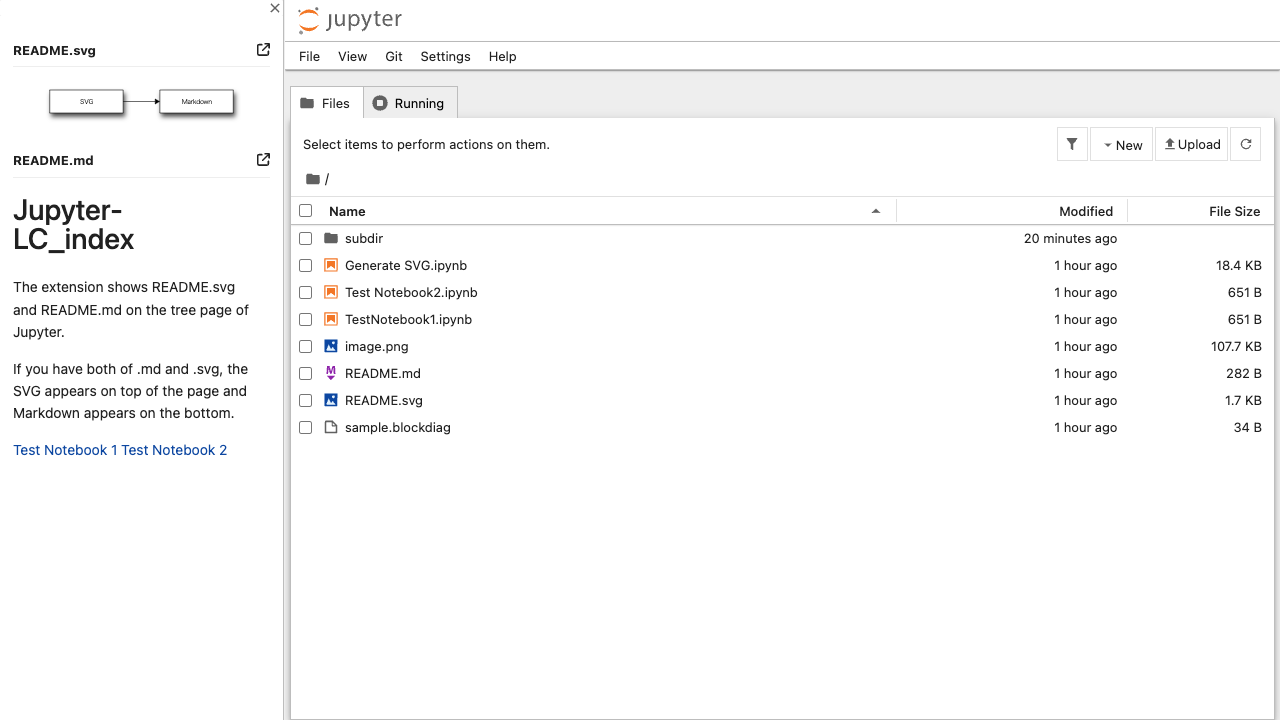

In [10]:
async def _step(page):
    # Verify that Index widget is visible in left sidebar (it's automatically displayed in Notebook 7)
    index_widget = page.locator('#lc_index\\:index-left-widget\\:')
    await expect(index_widget).to_be_visible(timeout=transition_timeout)
    
    # Verify it has the lc-index-widget class
    await expect(index_widget).to_have_class(re.compile(r'.*lc-index-widget.*'))
    
    print("Index widget is automatically visible in left sidebar")

await run_pw(_step)

## Verify Index content is displayed

Start epoch: 1763078861.304736 seconds
Index widget is visible in left sidebar
README.svg content (img tag) is visible in Index widget
Found 2 label widgets in Index


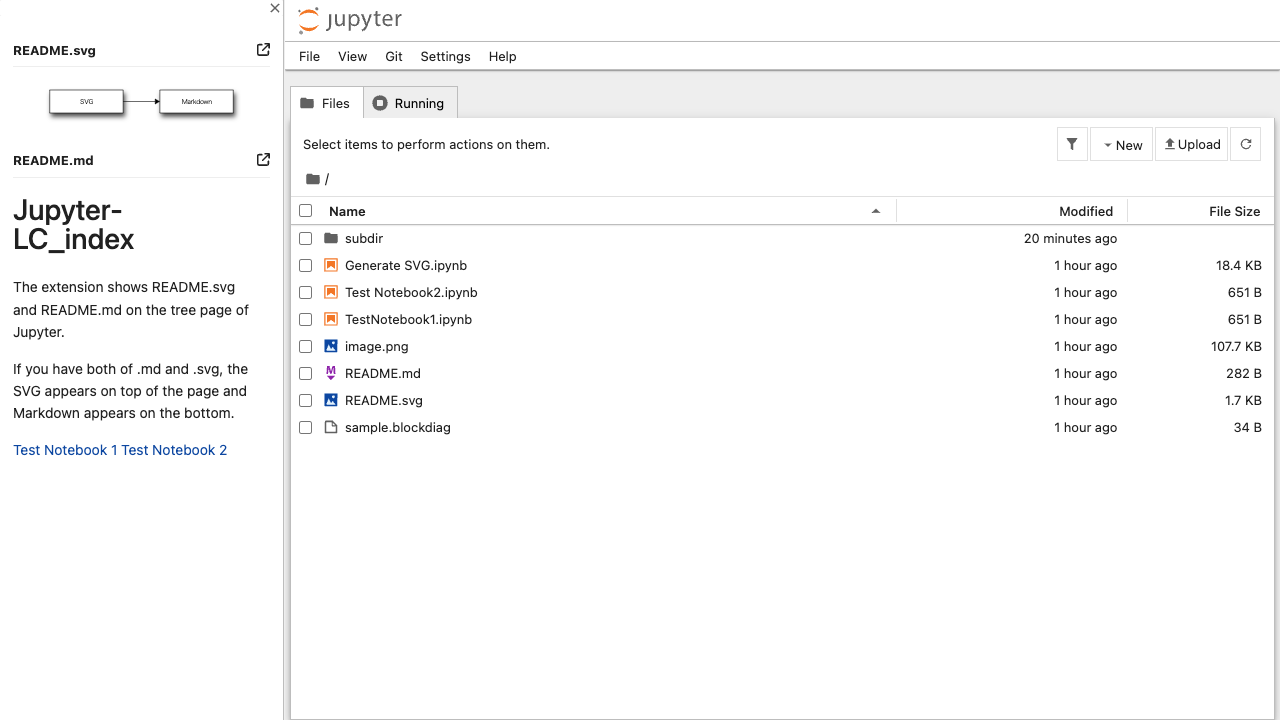

In [11]:
async def _step(page):
    # Index widget should already be visible in the left sidebar
    index_widget = page.locator('#lc_index\\:index-left-widget\\:')
    await expect(index_widget).to_be_visible(timeout=transition_timeout)
    
    print("Index widget is visible in left sidebar")
    
    # Verify that README.svg content is visible (SVG is embedded as img tag)
    img_content = index_widget.locator('img')
    await expect(img_content).to_be_visible(timeout=transition_timeout)
    
    print("README.svg content (img tag) is visible in Index widget")
    
    # Verify that label widgets are visible
    label_widgets = index_widget.locator('.lc-index-widget-label')
    label_count = await label_widgets.count()
    assert label_count >= 1, f"Expected at least 1 label widget, got {label_count}"
    
    print(f"Found {label_count} label widgets in Index")

await run_pw(_step)

## Click on Test Notebook 1 link in Index to open notebook in new tab

Start epoch: 1763078861.678797 seconds
TestNotebook1.ipynb opened in new tab: http://localhost:8888/notebooks/TestNotebook1.ipynb


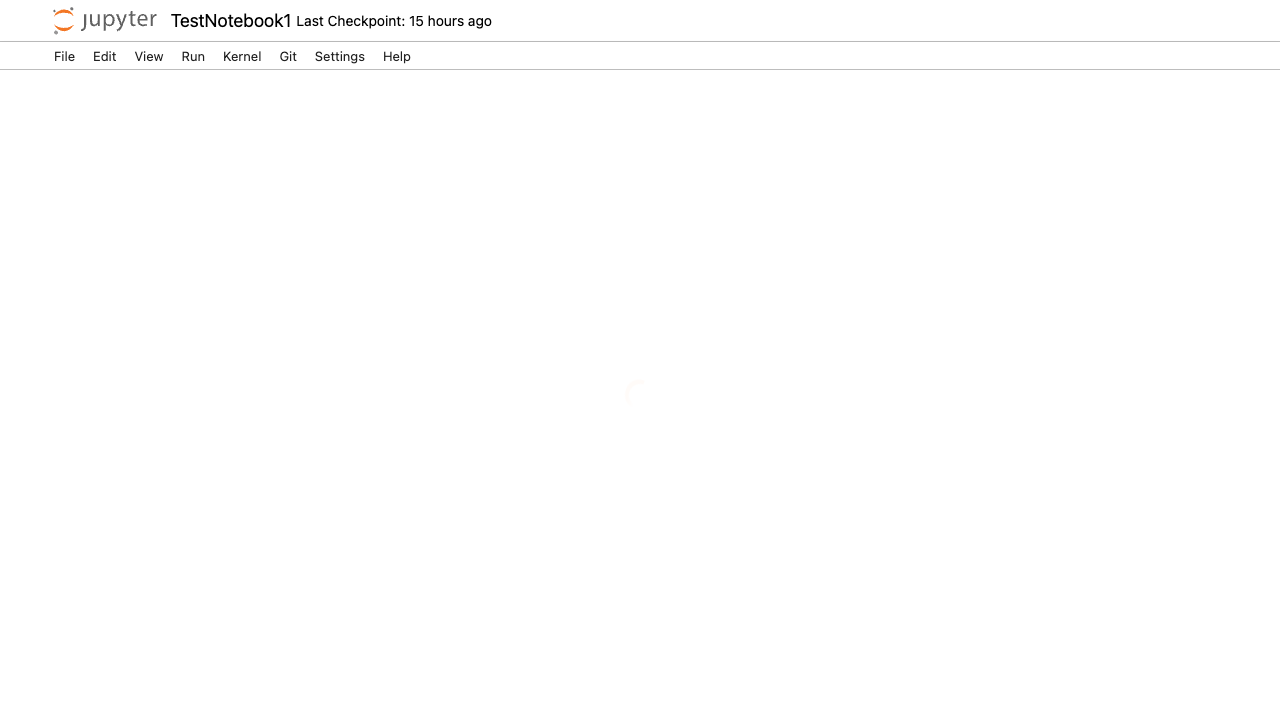

In [12]:
async def _step(page):
    index_widget = page.locator('#lc_index\\:index-left-widget\\:')
    
    # Wait for a new window (popup) to open when clicking the link
    popup_future = page.wait_for_event('popup', timeout=transition_timeout)
    
    # Click on Test Notebook 1 link in the Index content
    test_notebook_link = index_widget.locator('a:has-text("Test Notebook 1")')
    await expect(test_notebook_link).to_be_visible(timeout=transition_timeout)
    await test_notebook_link.click()
    
    # Wait for popup to open
    popup = await popup_future
    
    # Wait for the notebook to load in the new tab
    await expect(popup.locator('.jp-Notebook')).to_be_visible(timeout=transition_timeout)
    
    print(f"TestNotebook1.ipynb opened in new tab: {popup.url}")
    
    return popup

await run_pw(_step)

## Close the notebook tab and return to file browser

Start epoch: 1763078862.904939 seconds
Closed notebook, returned to file browser


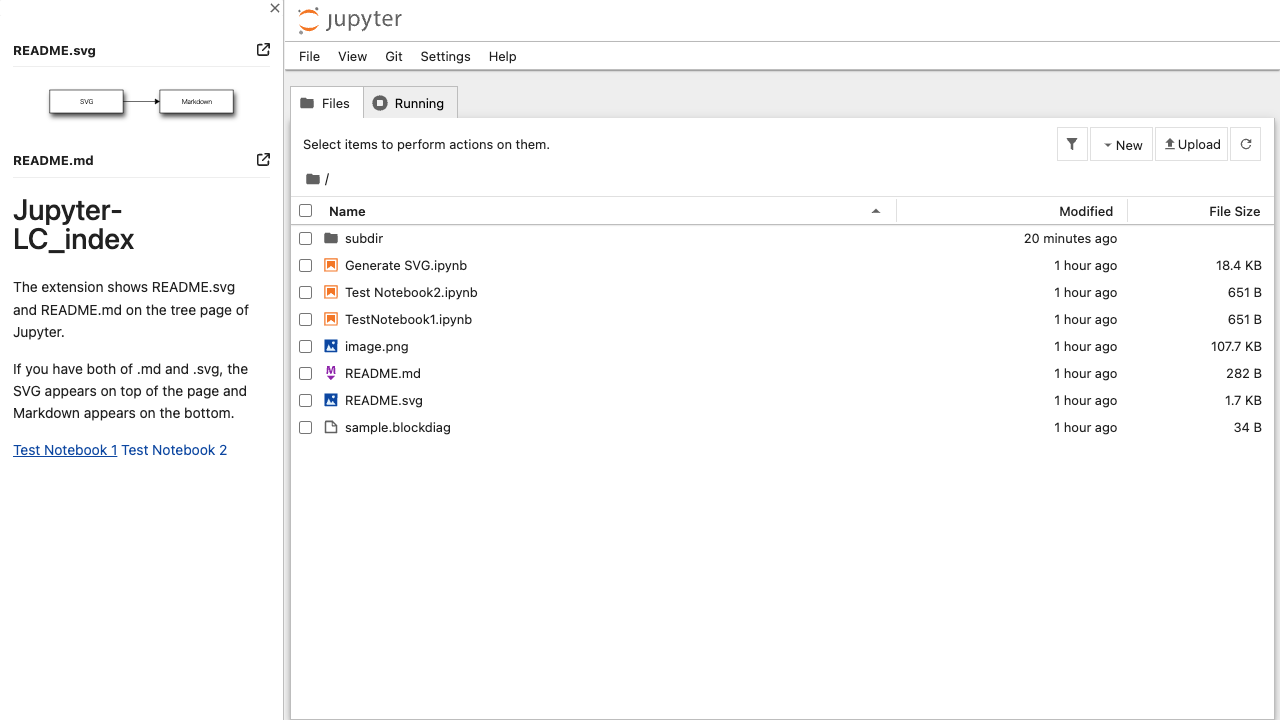

In [13]:
async def _step(page):
    print("Closed notebook, returned to file browser")

await close_latest_page()
await run_pw(_step)

## Navigate to subdirectory and verify Index updates

Start epoch: 1763078863.185475 seconds
Index widget updated with subdirectory content
SubNotebook1.ipynb opened from subdir Index: http://localhost:8888/notebooks/subdir/SubNotebook1.ipynb


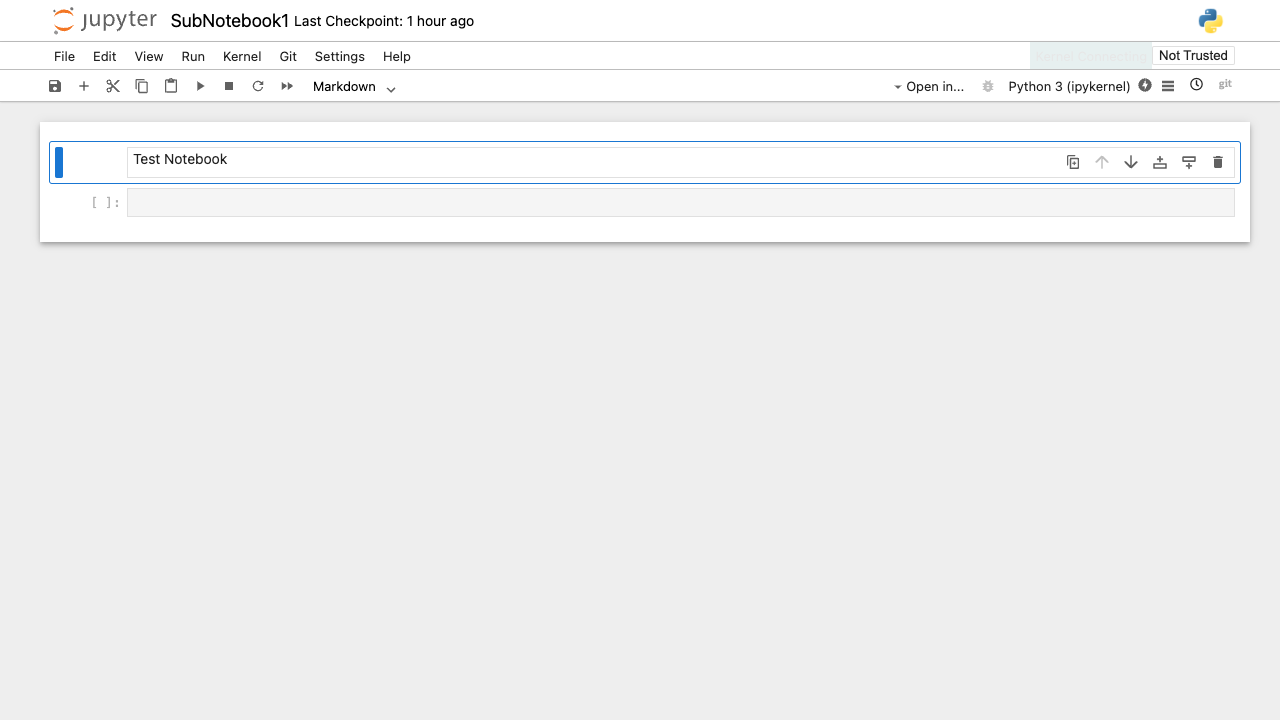

In [14]:
async def _step(page):
    # Double-click on subdir to navigate into it
    subdir = jupyterlab.get_file_browser_item_locator(page, 'subdir')
    await expect(subdir).to_be_visible(timeout=transition_timeout)
    await subdir.dblclick()
    
    # Wait for navigation to complete
    await asyncio.sleep(2)
    
    # Verify that Index widget in left sidebar updated
    index_widget = page.locator('#lc_index\\:index-left-widget\\:subdir')
    await expect(index_widget).to_be_visible(timeout=transition_timeout)
    
    img_content = index_widget.locator('img')
    await expect(img_content).to_be_visible(timeout=transition_timeout)
    
    print("Index widget updated with subdirectory content")
    
    # Wait for a new window (popup) to open when clicking the link
    popup_future = page.wait_for_event('popup', timeout=transition_timeout)
    
    # Click on Test Notebook 1 link in the subdir Index content
    sub_notebook_link = index_widget.locator('a:has-text("Test Notebook 1")')
    await expect(sub_notebook_link).to_be_visible(timeout=transition_timeout)
    await sub_notebook_link.click()
    
    # Wait for popup to open
    popup = await popup_future
    
    # Wait for the notebook to load in the new tab
    await expect(popup.locator('.jp-Notebook')).to_be_visible(timeout=transition_timeout)
    
    # Verify URL contains SubNotebook1 path
    assert 'SubNotebook1.ipynb' in popup.url, f"Expected SubNotebook1.ipynb in URL, got {popup.url}"
    
    print(f"SubNotebook1.ipynb opened from subdir Index: {popup.url}")
    
    return popup

await run_pw(_step)

## Close the notebook and navigate back to root

Start epoch: 1763078866.676686 seconds
Index widget updated back to root directory content
Test Notebook2.ipynb opened from root Index after navigating back: http://localhost:8888/notebooks/Test%20Notebook2.ipynb


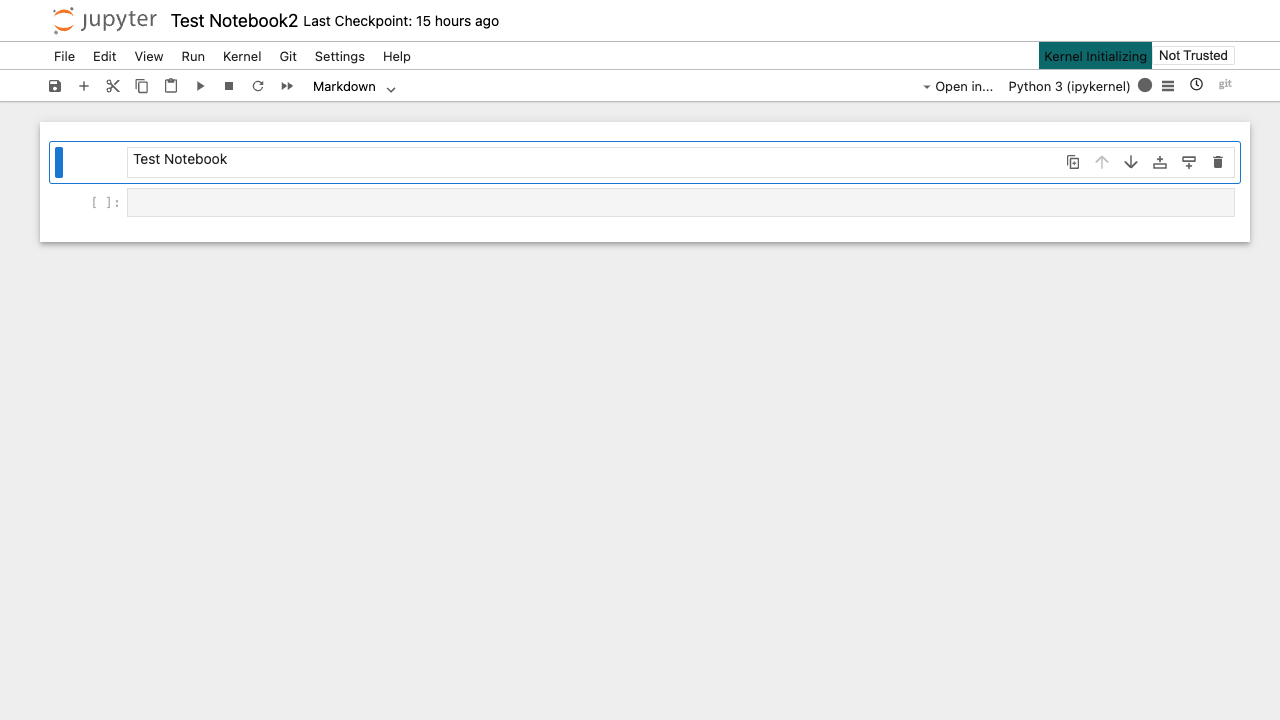

In [15]:
await close_latest_page()

async def _step(page):
    # Click on breadcrumb to go back to root
    breadcrumb = page.locator('.jp-FileBrowser-crumbs').locator('span').first
    await breadcrumb.click()
    
    # Wait for navigation to complete
    await asyncio.sleep(2)
    
    # Verify that root Index content is displayed again
    index_widget = page.locator('#lc_index\\:index-left-widget\\:')
    await expect(index_widget).to_be_visible(timeout=transition_timeout)
    
    img_content = index_widget.locator('img')
    await expect(img_content).to_be_visible(timeout=transition_timeout)
    
    label_widgets = index_widget.locator('.lc-index-widget-label')
    label_count = await label_widgets.count()
    assert label_count >= 1, f"Expected at least 1 label widget, got {label_count}"
    
    print("Index widget updated back to root directory content")
    
    # Wait for a new window (popup) to open when clicking the link
    popup_future = page.wait_for_event('popup', timeout=transition_timeout)
    
    # Click on Test Notebook 2 link to verify root directory link works
    test_notebook_link = index_widget.locator('a:has-text("Test Notebook 2")')
    await expect(test_notebook_link).to_be_visible(timeout=transition_timeout)
    await test_notebook_link.click()
    
    # Wait for popup to open
    popup = await popup_future
    
    # Wait for the notebook to load in the new tab
    await expect(popup.locator('.jp-Notebook')).to_be_visible(timeout=transition_timeout)
    
    # Verify URL contains Test Notebook2 (not Sub Notebook2)
    assert 'Test%20Notebook2.ipynb' in popup.url, f"Expected Test Notebook2.ipynb in URL, got {popup.url}"
    
    print(f"Test Notebook2.ipynb opened from root Index after navigating back: {popup.url}")
    
    return popup

await run_pw(_step)

## Clean up

Start epoch: 1763078869.786869 seconds


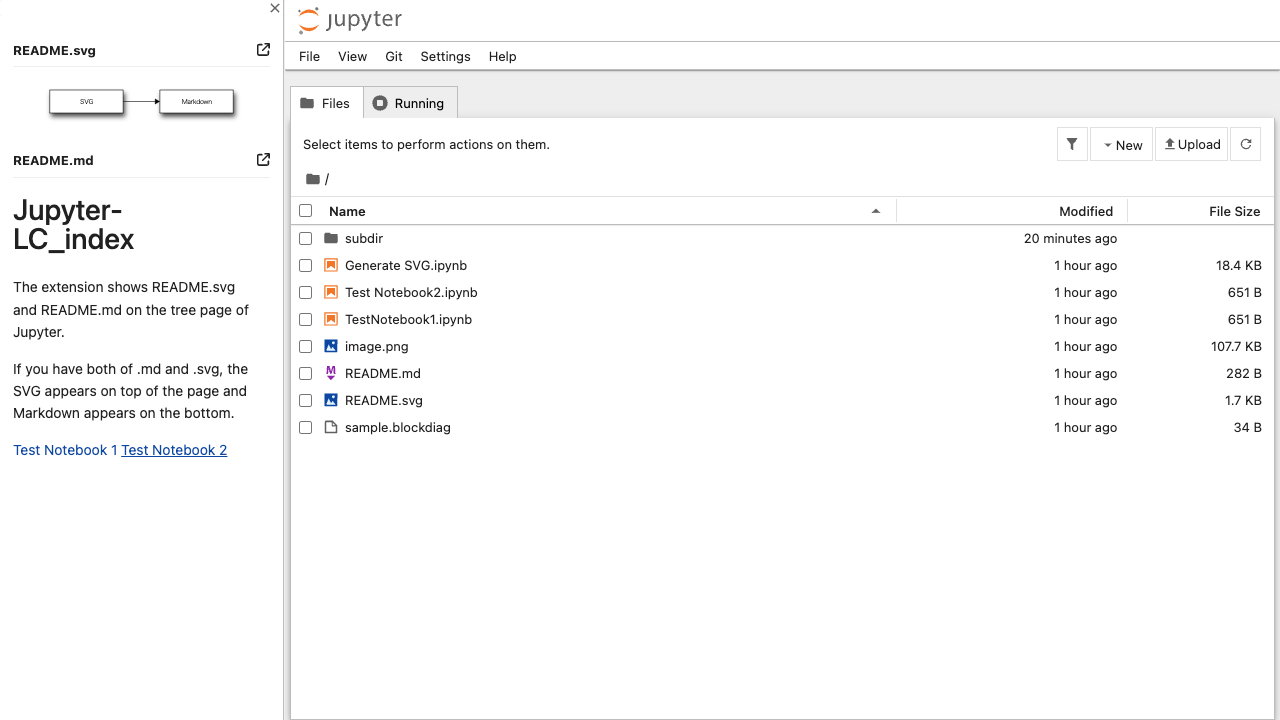

In [16]:
await close_latest_page()
await run_pw(None)

In [17]:
await finish_pw_context()

Video: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmptv19esji/video-1.webm
HAR: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmptv19esji/har.zip
Console log: /var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmptv19esji/console.log


スクリーンキャプチャ動画の取得に失敗しました。
Traceback (most recent call last):
  File "/Users/yazawa/workspace/nii-cloud/Jupyter-LC_index/ui-tests/e2e-notebook/notebooks/scripts/playwright.py", line 254, in _finish_pw_context
    shutil.copyfile(video_path, dest_video_path)
  File "/Users/yazawa/.pyenv/versions/3.11.5/lib/python3.11/shutil.py", line 256, in copyfile
    with open(src, 'rb') as fsrc:
         ^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/var/folders/m0/myy2ys0s3cl_73__2gw8fw140000gn/T/tmpn8gj44f6/videos/d7cf5c0b412ecbb5b16c2e9d4c1a4ae0.webm'


In [18]:
!rm -fr {work_dir}